<a href="https://colab.research.google.com/github/Saisohangoud/YouTube-Trending-Analysis/blob/main/YouTube_Trending_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("INvideos.csv")

# Show dataset
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...


**Dataset Information**

In [2]:
# Dataset shape

print("Dataset Shape:")
print(df.shape)

# Column names

print("\nColumns:")
print(df.columns)

# Missing values

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(37352, 16)

Columns:
Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='object')

Missing Values:
video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               561
dtype: int64


**Data Cleaning**

In [3]:
# Remove duplicates

df.drop_duplicates(inplace=True)

# Fill missing descriptions

df['description'] = df['description'].fillna('No Description')

print("Data Cleaned Successfully")

Data Cleaned Successfully


**Top Trending Channels Graph**

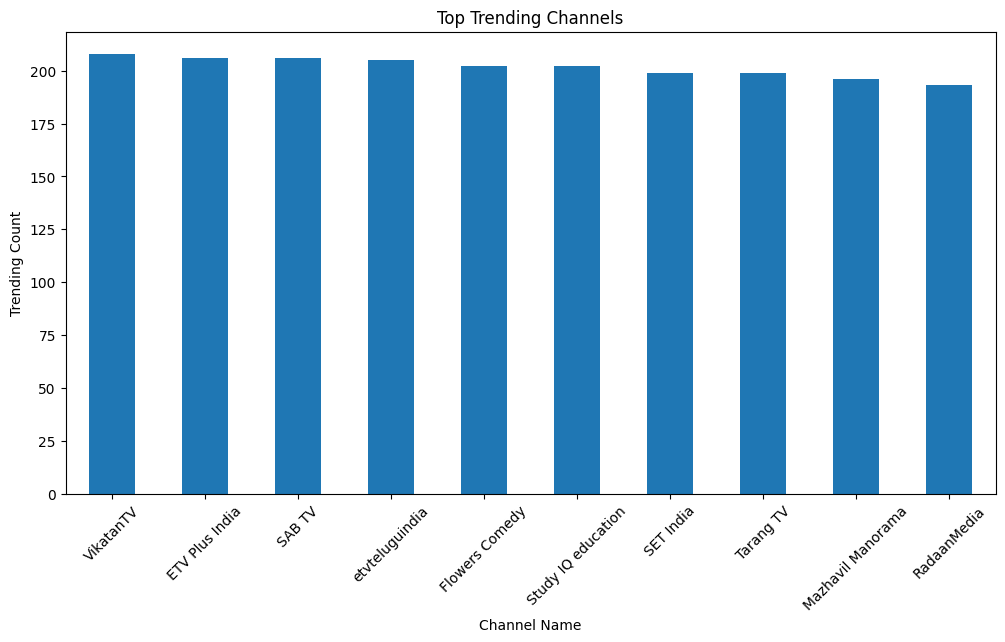

In [4]:
# Top 10 trending channels

top_channels = df['channel_title'].value_counts().head(10)

plt.figure(figsize=(12,6))

top_channels.plot(kind='bar')

plt.title("Top Trending Channels")
plt.xlabel("Channel Name")
plt.ylabel("Trending Count")

plt.xticks(rotation=45)

plt.show()

**Likes vs Views Scatter Plot**

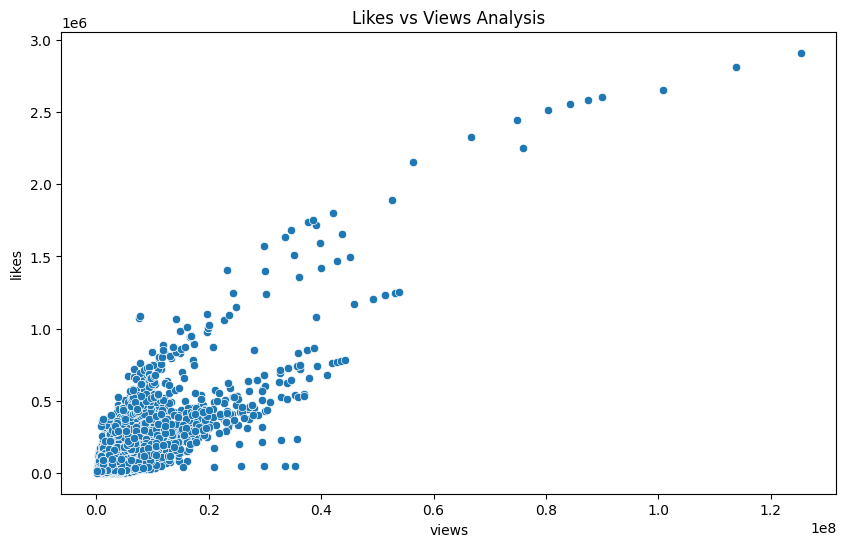

In [5]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='views',
    y='likes',
    data=df
)

plt.title("Likes vs Views Analysis")

plt.show()

**Correlation Heatmap**

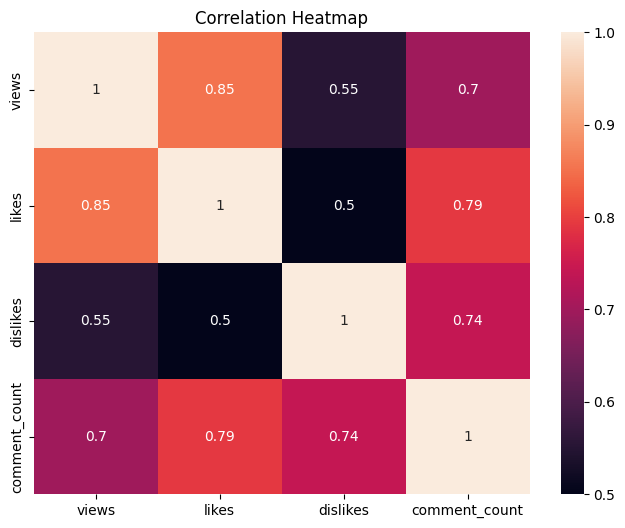

In [6]:
# Correlation analysis

correlation = df[['views', 'likes', 'dislikes', 'comment_count']].corr()

plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")

plt.show()

**Most Viewed Videos**

In [7]:
# Top viewed videos

top_videos = df[['title', 'channel_title', 'views']].sort_values(
    by='views',
    ascending=False
).head(10)

top_videos

,title,channel_title,views
5408,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,125432237
5119,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,113876217
4936,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,100911567
4477,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,89930713
4236,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,87449453
4013,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,84281319
3823,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,80360459
4743,YouTube Rewind: The Shape of 2017 | #YouTubeRe...,YouTube Spotlight,75969469
3639,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,74789251
3456,Marvel Studios' Avengers: Infinity War Officia...,Marvel Entertainment,66637636


**Category Analysis**

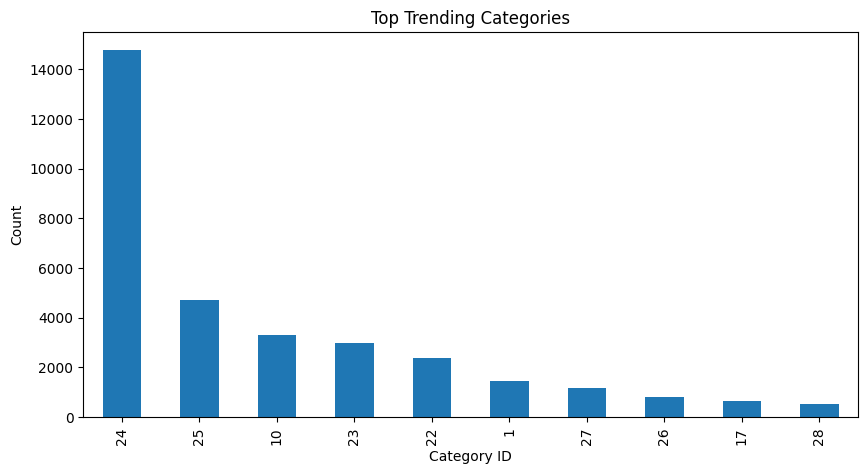

In [8]:
# Top categories

top_categories = df['category_id'].value_counts().head(10)

plt.figure(figsize=(10,5))

top_categories.plot(kind='bar')

plt.title("Top Trending Categories")
plt.xlabel("Category ID")
plt.ylabel("Count")

plt.show()

**Pie Chart**

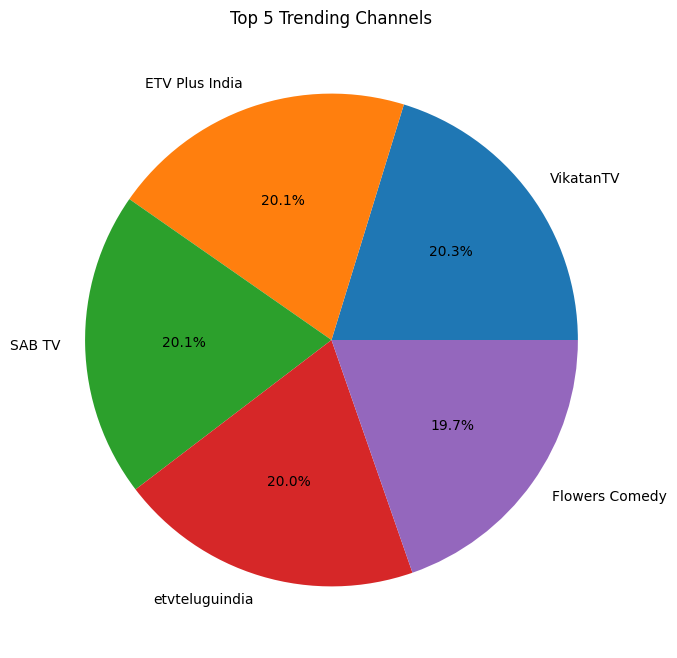

In [9]:
# Top 5 channels pie chart

top5 = df['channel_title'].value_counts().head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top5,
    labels=top5.index,
    autopct='%1.1f%%'
)

plt.title("Top 5 Trending Channels")

plt.show()

**Final Insights**

In [10]:
print("PROJECT INSIGHTS")
print("---------------------")

print("1. Certain channels dominate YouTube trending repeatedly.")

print("2. Videos with higher views generally receive higher likes.")

print("3. Viewer engagement metrics are strongly correlated.")

print("4. Entertainment and music categories trend most frequently.")

print("5. Trending videos generate massive audience interaction.")

PROJECT INSIGHTS
---------------------
1. Certain channels dominate YouTube trending repeatedly.
2. Videos with higher views generally receive higher likes.
3. Viewer engagement metrics are strongly correlated.
4. Entertainment and music categories trend most frequently.
5. Trending videos generate massive audience interaction.
